# Model Inspector

Load a `.pt` checkpoint and inspect its weight distributions, layer statistics, and structure.

Works with **WP1 checkpoints** (full `ActorCriticTanh`) or **standalone actor checkpoints** (state-dict-only `.pt` files).

In [4]:
# ── Configuration ──────────────────────────────────────────────────────────────
CHECKPOINT_PATH = "../logs/remote/wp1_training/wp1_intermediate_single_65536_32_010_r2/logs/runs/2026-05-18_21-11-05_intermediate_single_65536_32_010/tb/model_999.pt"

# Optional: compare a second checkpoint (set to None to skip)
CHECKPOINT_PATH_B = None
# e.g. CHECKPOINT_PATH_B = "../logs/runs_hebbian/2026-04-10_.../reproducibility/wp1_actor.pt"
# ───────────────────────────────────────────────────────────────────────────────

In [5]:
import sys
import math
from pathlib import Path

import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
import matplotlib.ticker as ticker

# Make src importable (needed for WP1 / ActorCriticTanh)
repo_root = Path("../").resolve()
src_path  = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

print(f"PyTorch {torch.__version__} | device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch 2.10.0+cu128 | device: cuda


## 1 · Load checkpoint

In [6]:
def load_state_dict(path: str) -> dict:
    """Load a .pt file and return a flat {name: tensor} state dict."""
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    if isinstance(ckpt, dict):
        if "model_state_dict" in ckpt:
            sd = ckpt["model_state_dict"]
            meta = {k: v for k, v in ckpt.items() if k != "model_state_dict"}
        elif any(isinstance(v, torch.Tensor) for v in ckpt.values()):
            sd = ckpt
            meta = {}
        else:
            raise ValueError(f"Unrecognised checkpoint format. Top-level keys: {list(ckpt.keys())}")
    else:
        raise TypeError(f"Expected dict checkpoint, got {type(ckpt)}")
    return sd, meta


sd_a, meta_a = load_state_dict(CHECKPOINT_PATH)

print(f"Loaded: {CHECKPOINT_PATH}")
if "iter" in meta_a:
    print(f"  Training iteration : {meta_a['iter']}")
print(f"  Tensor keys ({len(sd_a)}):")
for name, t in sd_a.items():
    print(f"    {name:50s}  {str(tuple(t.shape)):20s}  dtype={t.dtype}")

Loaded: ../logs/remote/wp1_training/wp1_intermediate_single_65536_32_010_r2/logs/runs/2026-05-18_21-11-05_intermediate_single_65536_32_010/tb/model_999.pt
  Training iteration : 999
  Tensor keys (21):
    std                                                 (7,)                  dtype=torch.float32
    actor.0.weight                                      (128, 128)            dtype=torch.float32
    actor.0.bias                                        (128,)                dtype=torch.float32
    actor.2.weight                                      (32, 128)             dtype=torch.float32
    actor.2.bias                                        (32,)                 dtype=torch.float32
    actor.4.weight                                      (7, 32)               dtype=torch.float32
    actor.4.bias                                        (7,)                  dtype=torch.float32
    critic.0.weight                                     (128, 128)            dtype=torch.float32
    critic.0.b

In [7]:
# Optionally load checkpoint B for comparison
sd_b, meta_b = (None, {}) if CHECKPOINT_PATH_B is None else load_state_dict(CHECKPOINT_PATH_B)

if sd_b is not None:
    print(f"Checkpoint B: {CHECKPOINT_PATH_B}")
    if "iter" in meta_b:
        print(f"  Iteration: {meta_b['iter']}")
else:
    print("No checkpoint B loaded (single-checkpoint mode).")

No checkpoint B loaded (single-checkpoint mode).


## 2 · Per-layer statistics

In [8]:
def layer_stats(sd: dict) -> list[dict]:
    """Compute scalar statistics for every weight/bias tensor."""
    rows = []
    for name, t in sd.items():
        v = t.float().numpy().ravel()
        rows.append(dict(
            name    = name,
            shape   = tuple(t.shape),
            numel   = v.size,
            mean    = float(np.mean(v)),
            std     = float(np.std(v)),
            min_    = float(np.min(v)),
            max_    = float(np.max(v)),
            abs_mean= float(np.mean(np.abs(v))),
            l2_norm = float(np.linalg.norm(v)),
            sparsity= float(np.mean(np.abs(v) < 1e-6)),
        ))
    return rows


stats_a = layer_stats(sd_a)

# Pretty-print as a table
hdr = f"{'Layer':50s} {'Shape':18s} {'N':>7}  {'mean':>8}  {'std':>8}  {'min':>8}  {'max':>8}  {'|mean|':>8}  {'L2':>8}  {'sparse':>7}"
print(hdr)
print("-" * len(hdr))
for r in stats_a:
    print(f"{r['name']:50s} {str(r['shape']):18s} {r['numel']:>7d}  "
          f"{r['mean']:>8.4f}  {r['std']:>8.4f}  {r['min_']:>8.4f}  {r['max_']:>8.4f}  "
          f"{r['abs_mean']:>8.4f}  {r['l2_norm']:>8.3f}  {r['sparsity']:>6.1%}")

Layer                                              Shape                    N      mean       std       min       max    |mean|        L2   sparse
--------------------------------------------------------------------------------------------------------------------------------------------------
std                                                (7,)                     7    0.1344    0.0471    0.0647    0.1879    0.1344     0.377    0.0%
actor.0.weight                                     (128, 128)           16384    0.0001    0.1280   -1.1077    0.7985    0.0850    16.385    0.0%
actor.0.bias                                       (128,)                 128   -0.0044    0.0411   -0.1881    0.1026    0.0294     0.468    0.0%
actor.2.weight                                     (32, 128)             4096   -0.0003    0.0622   -0.3902    0.4470    0.0336     3.980    0.0%
actor.2.bias                                       (32,)                   32   -0.0041    0.0643   -0.1540    0.2538    0

## 3 · Weight-distribution histograms (per layer)

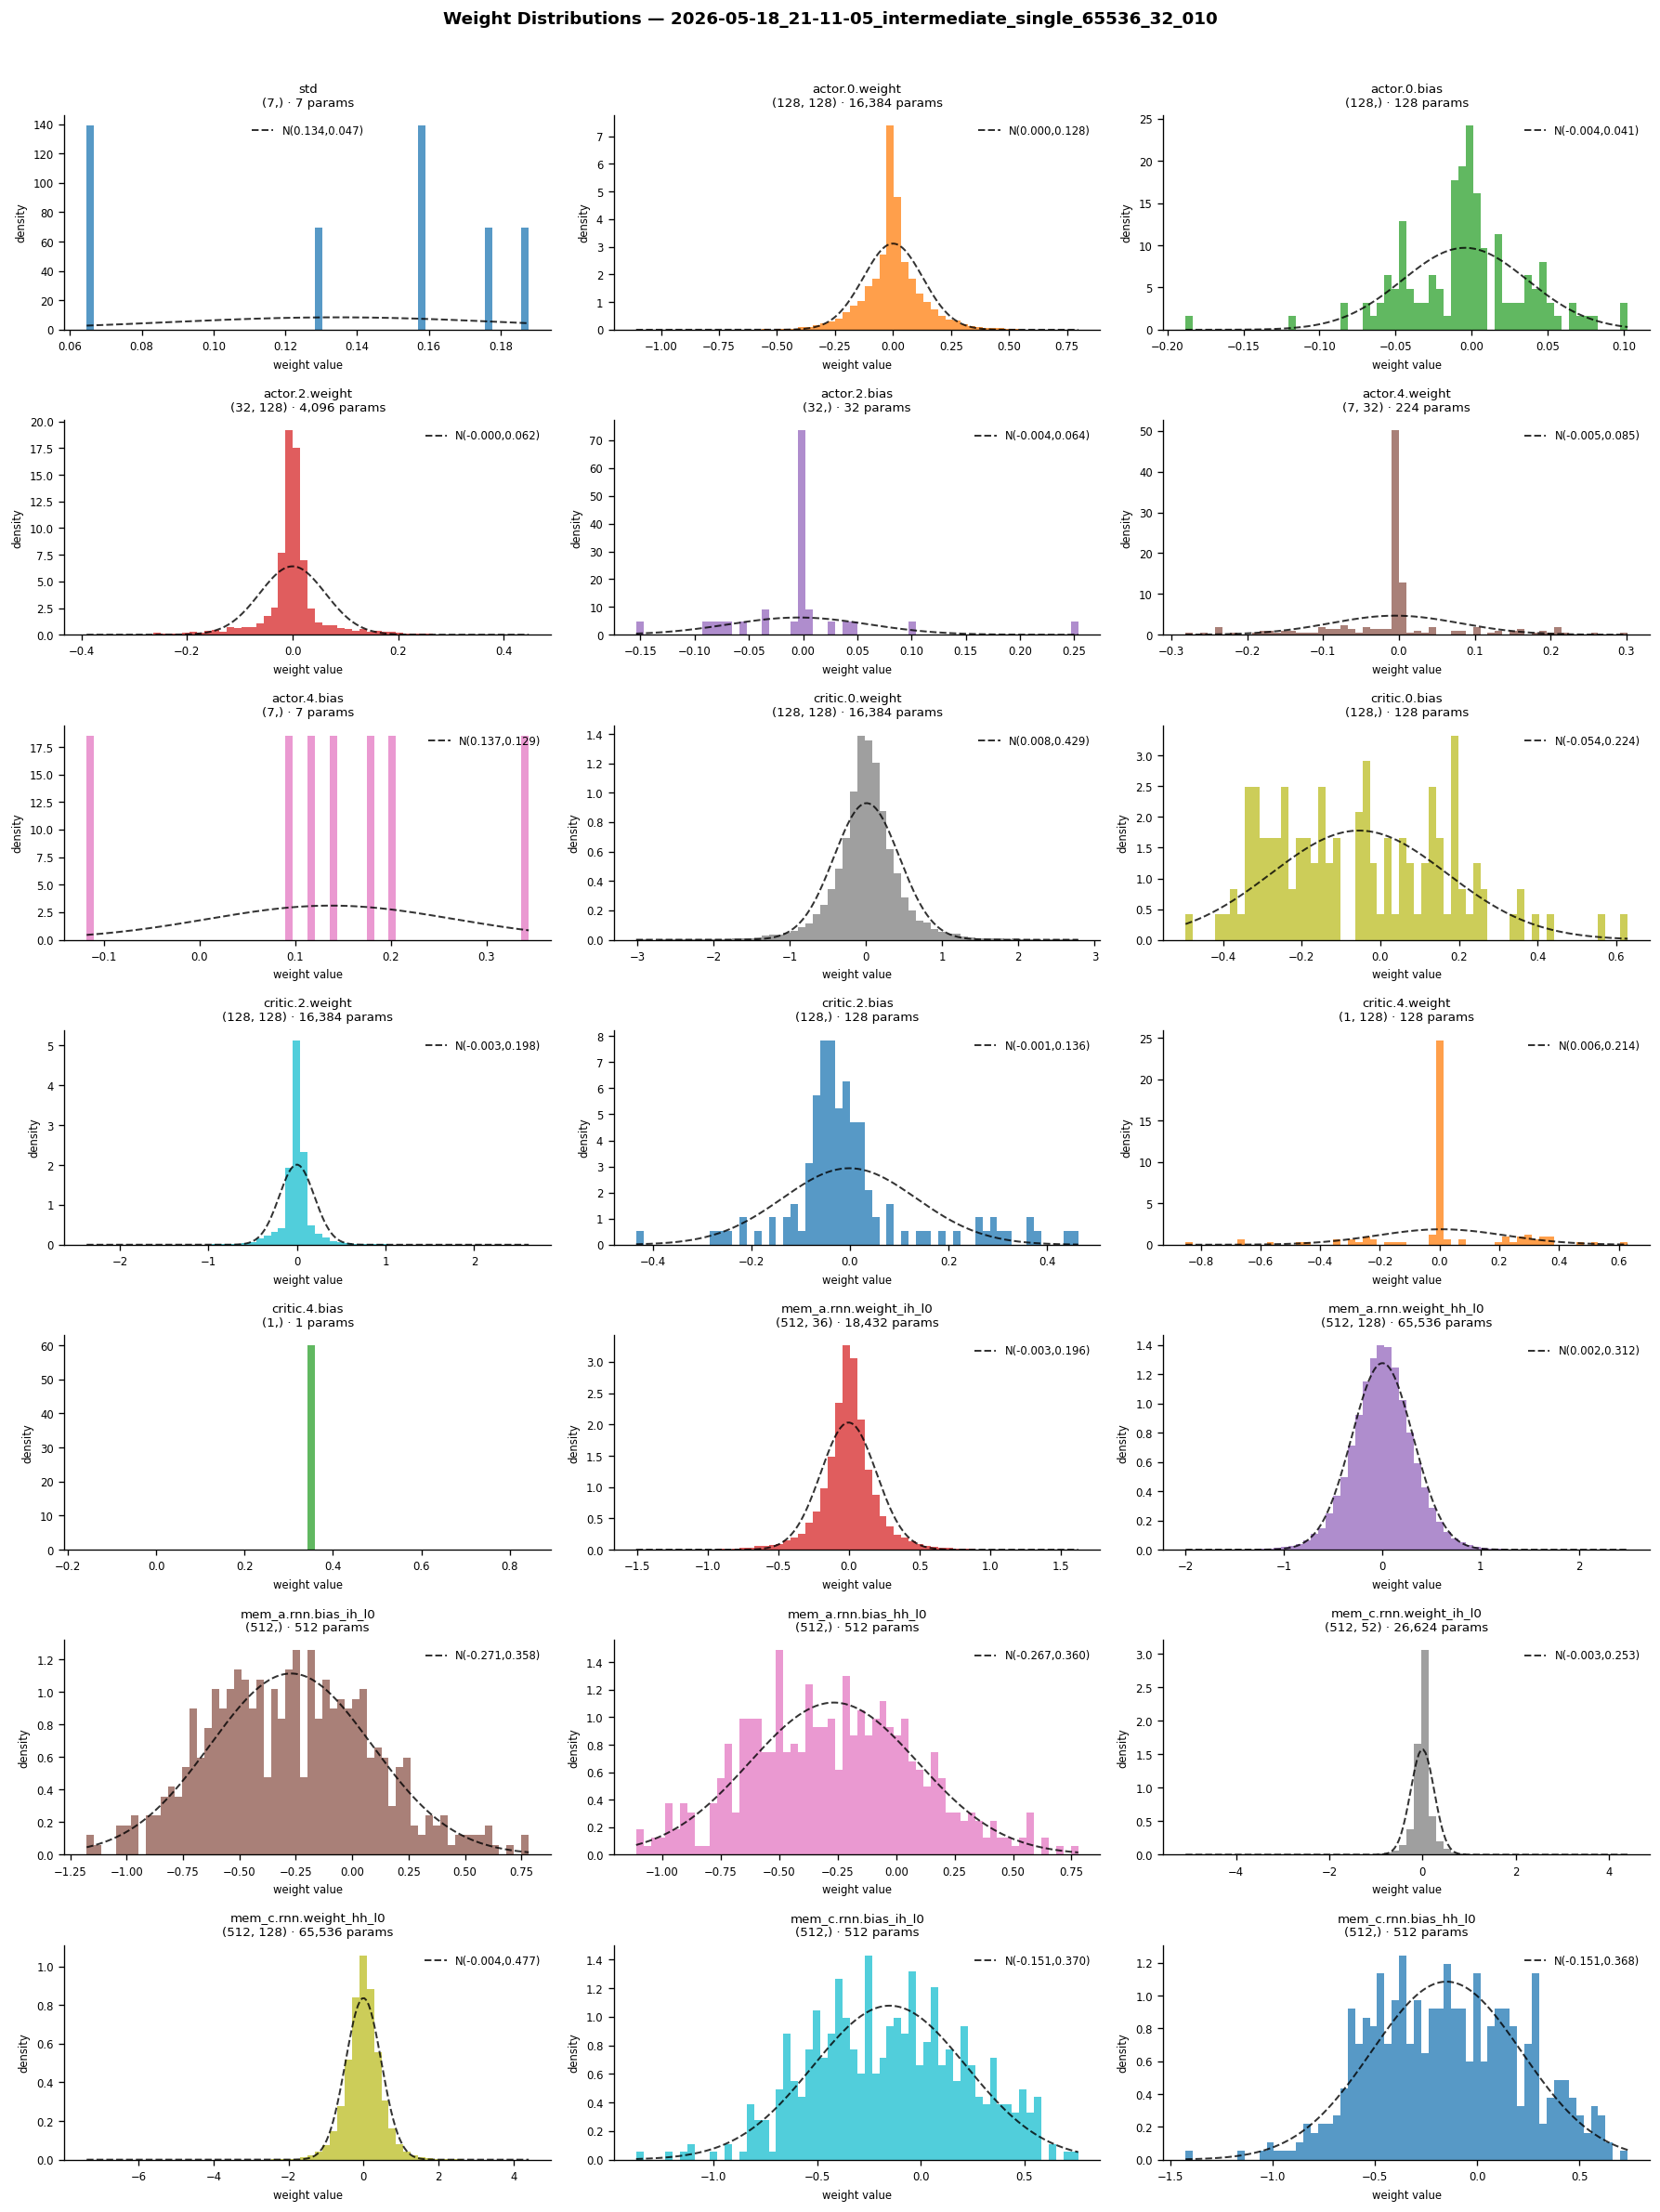

In [9]:
def plot_histograms(sd: dict, title_prefix: str = "", bins: int = 60):
    """One subplot per tensor — histogram + KDE-style fit overlay."""
    keys = list(sd.keys())
    n    = len(keys)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 2.8))
    axes = np.array(axes).ravel()

    cmap = plt.cm.tab10
    for i, (name, t) in enumerate(sd.items()):
        ax  = axes[i]
        v   = t.float().numpy().ravel()
        col = cmap(i % 10)

        ax.hist(v, bins=bins, color=col, alpha=0.75, density=True, linewidth=0)

        # Overlay Gaussian fit
        mu, sigma = v.mean(), v.std()
        if sigma > 1e-9:
            xs = np.linspace(v.min(), v.max(), 200)
            ax.plot(xs, np.exp(-0.5 * ((xs - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi)),
                    "k--", linewidth=1.2, alpha=0.8, label=f"N({mu:.3f},{sigma:.3f})")
            ax.legend(fontsize=7, frameon=False)

        label = name.replace("memory_a.", "mem_a.").replace("memory_c.", "mem_c.")
        ax.set_title(f"{title_prefix}{label}\n{str(tuple(t.shape))} · {v.size:,} params",
                     fontsize=8)
        ax.set_xlabel("weight value", fontsize=7)
        ax.set_ylabel("density", fontsize=7)
        ax.tick_params(labelsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"{title_prefix}Weight Distributions — {Path(CHECKPOINT_PATH).parent.parent.name}",
                 fontsize=11, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()


plot_histograms(sd_a)

## 4 · Weight magnitude overview (bar chart)

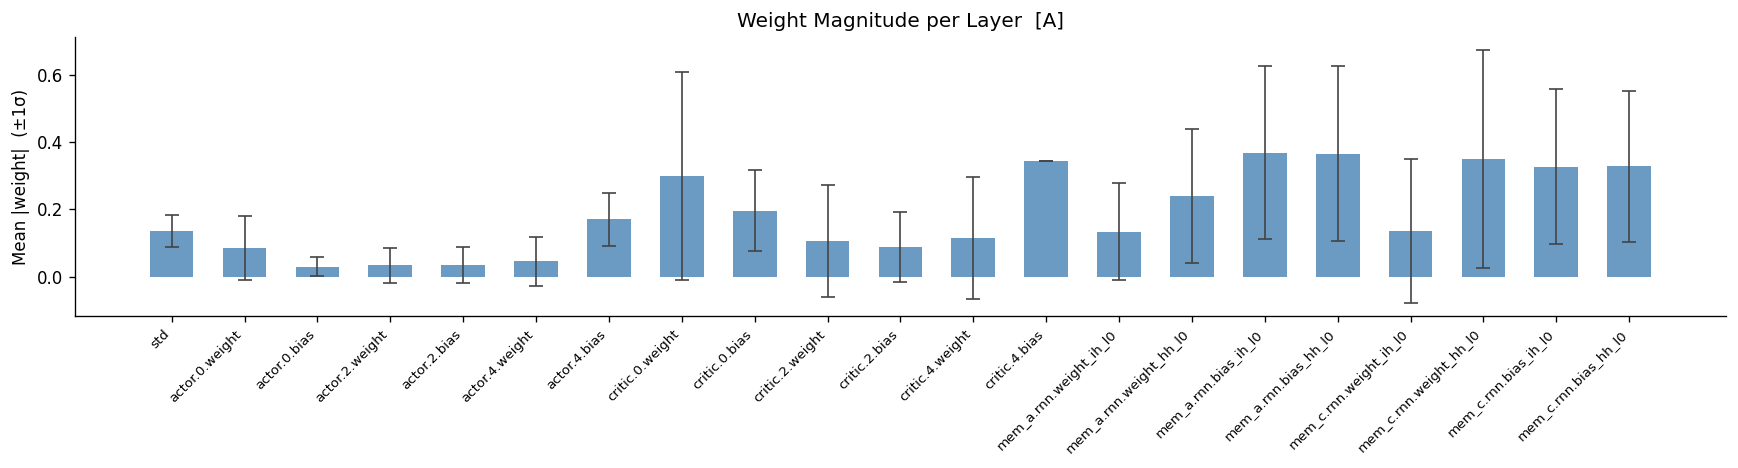

In [10]:
def plot_magnitude_overview(sd: dict, label: str = "A"):
    """Bar chart: mean |w| and ±1σ per layer."""
    names, means, stds = [], [], []
    for name, t in sd.items():
        v = np.abs(t.float().numpy().ravel())
        names.append(name.replace("memory_a.", "mem_a.").replace("memory_c.", "mem_c."))
        means.append(v.mean())
        stds.append(v.std())

    x = np.arange(len(names))
    fig, ax = plt.subplots(figsize=(max(8, len(names) * 0.7), 4))
    bars = ax.bar(x, means, yerr=stds, capsize=4, color="steelblue", alpha=0.8, width=0.6,
                  error_kw=dict(elinewidth=1, ecolor="#444"))
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Mean |weight|  (±1σ)")
    ax.set_title(f"Weight Magnitude per Layer  [{label}]")
    fig.tight_layout()
    plt.show()


plot_magnitude_overview(sd_a, label="A")
if sd_b is not None:
    plot_magnitude_overview(sd_b, label="B")

## 5 · Weight matrix heatmaps

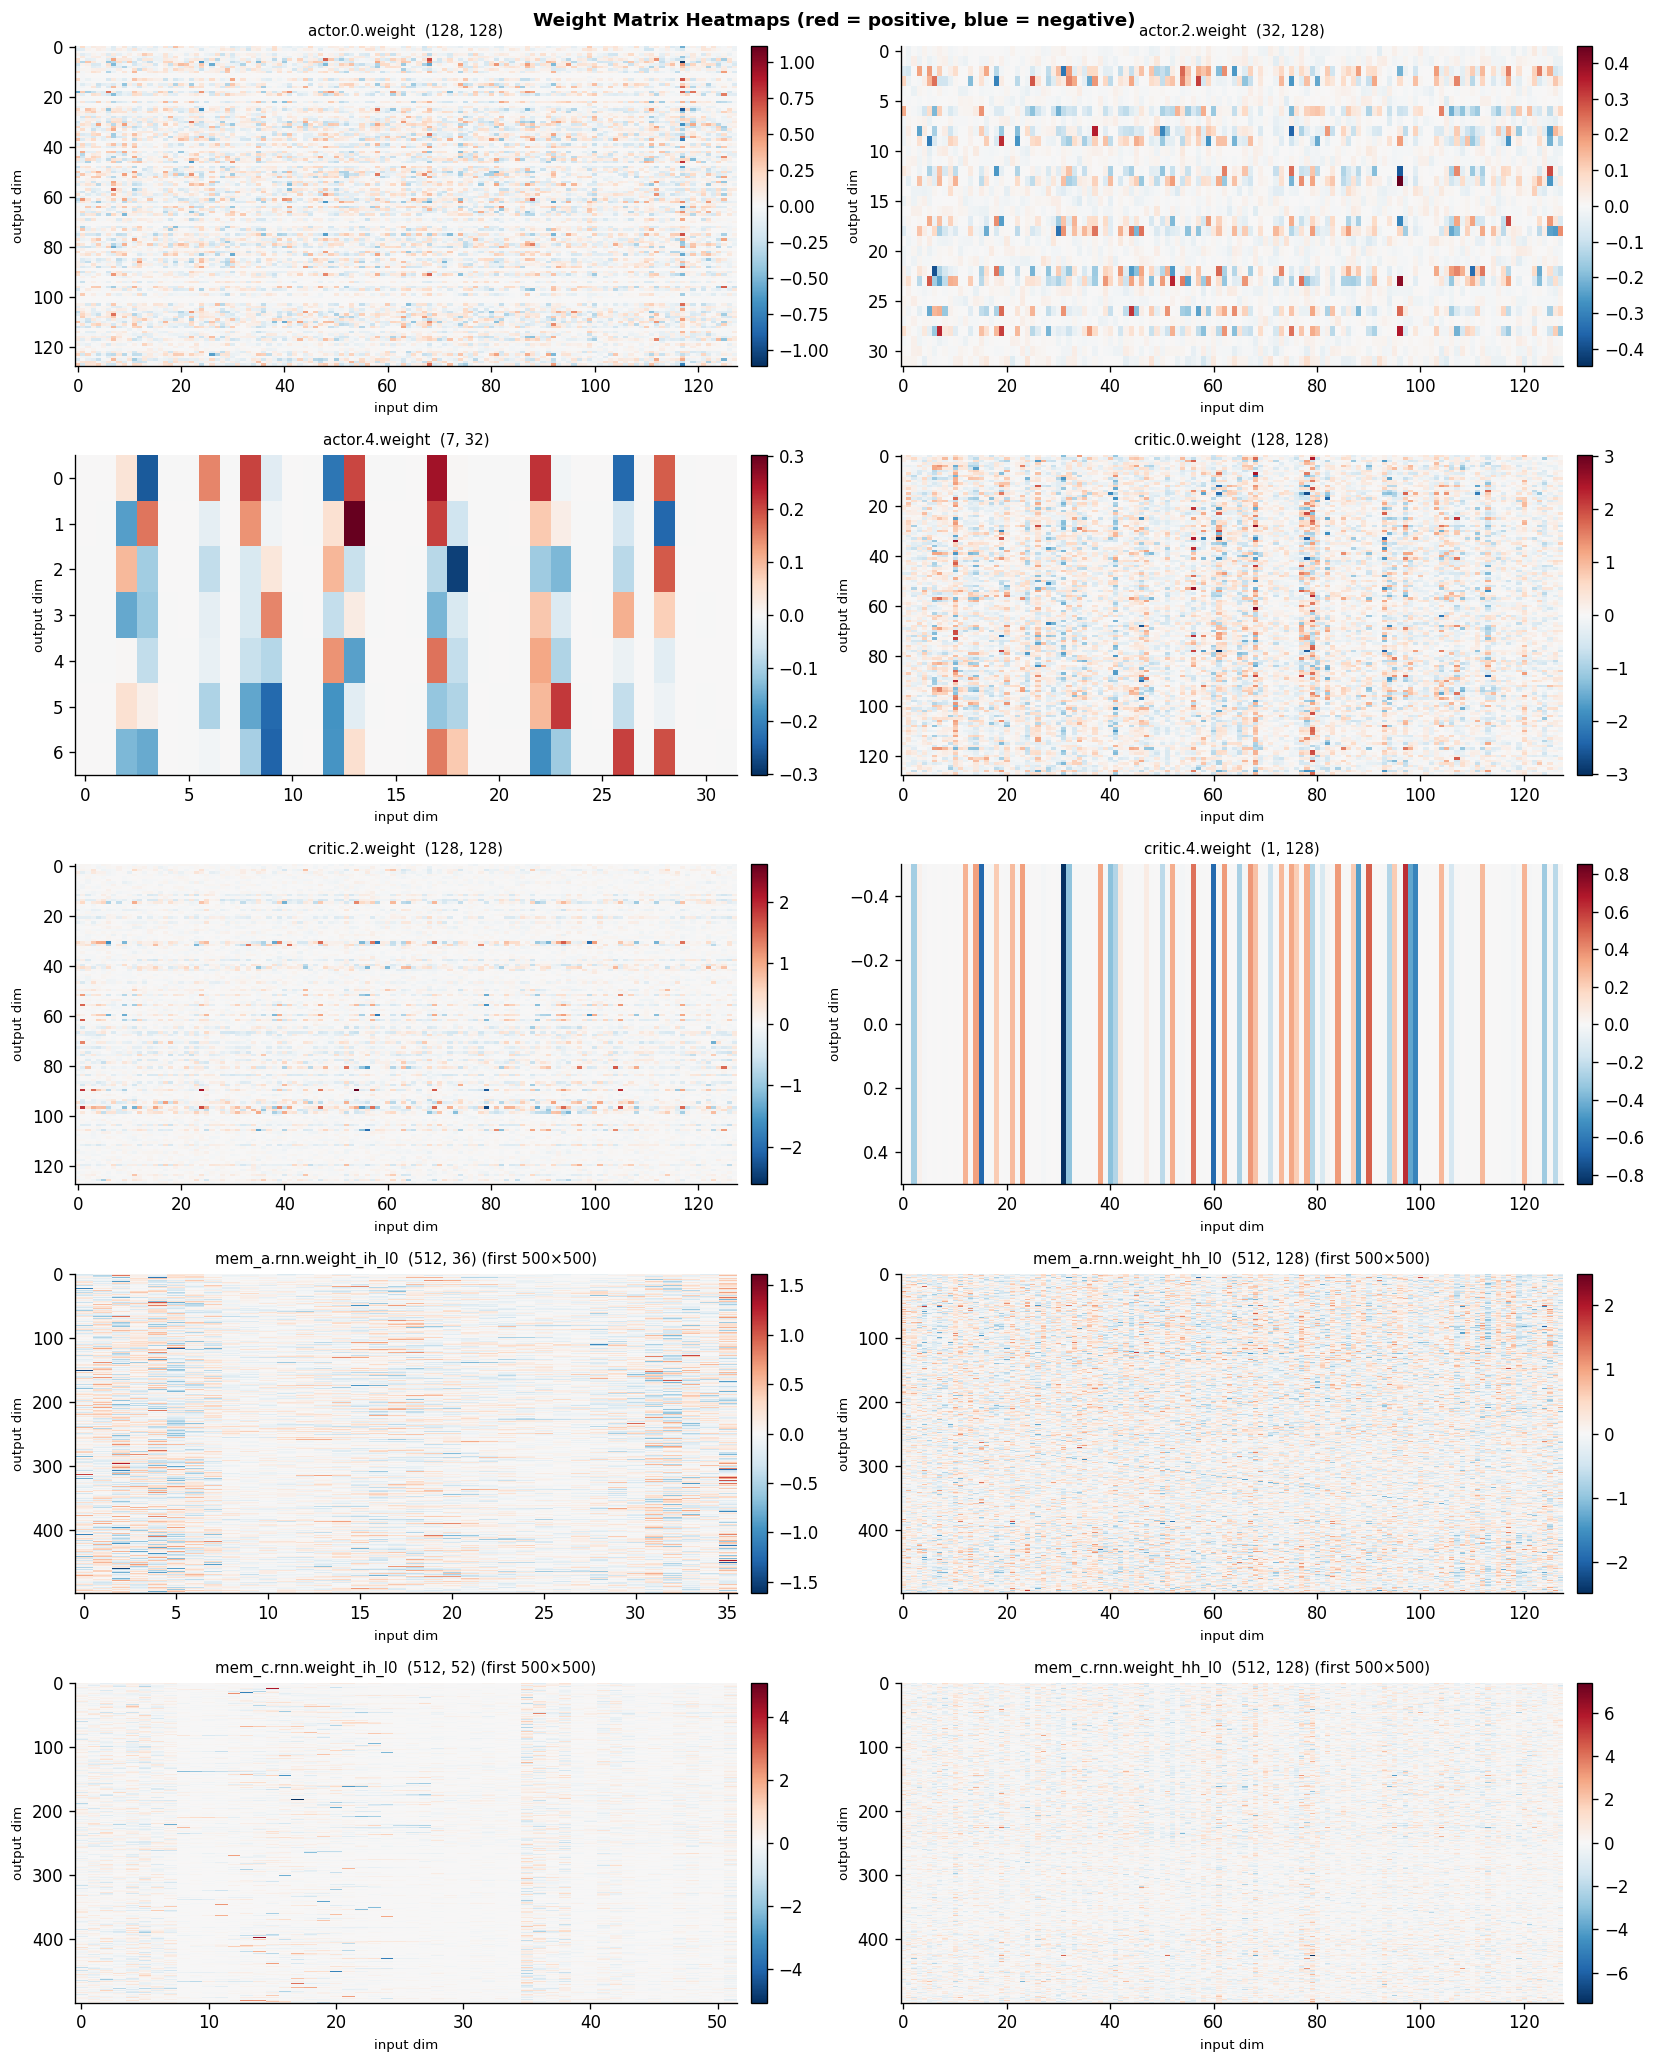

In [11]:
def plot_weight_heatmaps(sd: dict, max_cols: int = 500, max_rows: int = 500):
    """Heatmap of each 2-D weight matrix (truncated if too large)."""
    weight_keys = [k for k, v in sd.items() if v.dim() == 2]
    if not weight_keys:
        print("No 2-D weight tensors found.")
        return

    ncols = 2
    nrows = math.ceil(len(weight_keys) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 7, nrows * 3.5))
    axes = np.array(axes).ravel()

    for i, key in enumerate(weight_keys):
        ax = axes[i]
        mat = sd[key].float().numpy()
        r, c = mat.shape
        truncated = r > max_rows or c > max_cols
        mat_disp  = mat[:max_rows, :max_cols]

        vabs = max(abs(mat_disp.min()), abs(mat_disp.max()), 1e-9)
        norm = TwoSlopeNorm(vmin=-vabs, vcenter=0, vmax=vabs)
        im   = ax.imshow(mat_disp, aspect="auto", cmap="RdBu_r", norm=norm, interpolation="nearest")
        plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)

        suffix = f" (first {max_rows}×{max_cols})" if truncated else ""
        label  = key.replace("memory_a.", "mem_a.").replace("memory_c.", "mem_c.")
        ax.set_title(f"{label}  {mat.shape}{suffix}", fontsize=9)
        ax.set_xlabel("input dim", fontsize=8)
        ax.set_ylabel("output dim", fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Weight Matrix Heatmaps (red = positive, blue = negative)",
                 fontsize=11, fontweight="bold")
    fig.tight_layout()
    plt.show()


plot_weight_heatmaps(sd_a)

## 6 · Singular value spectrum

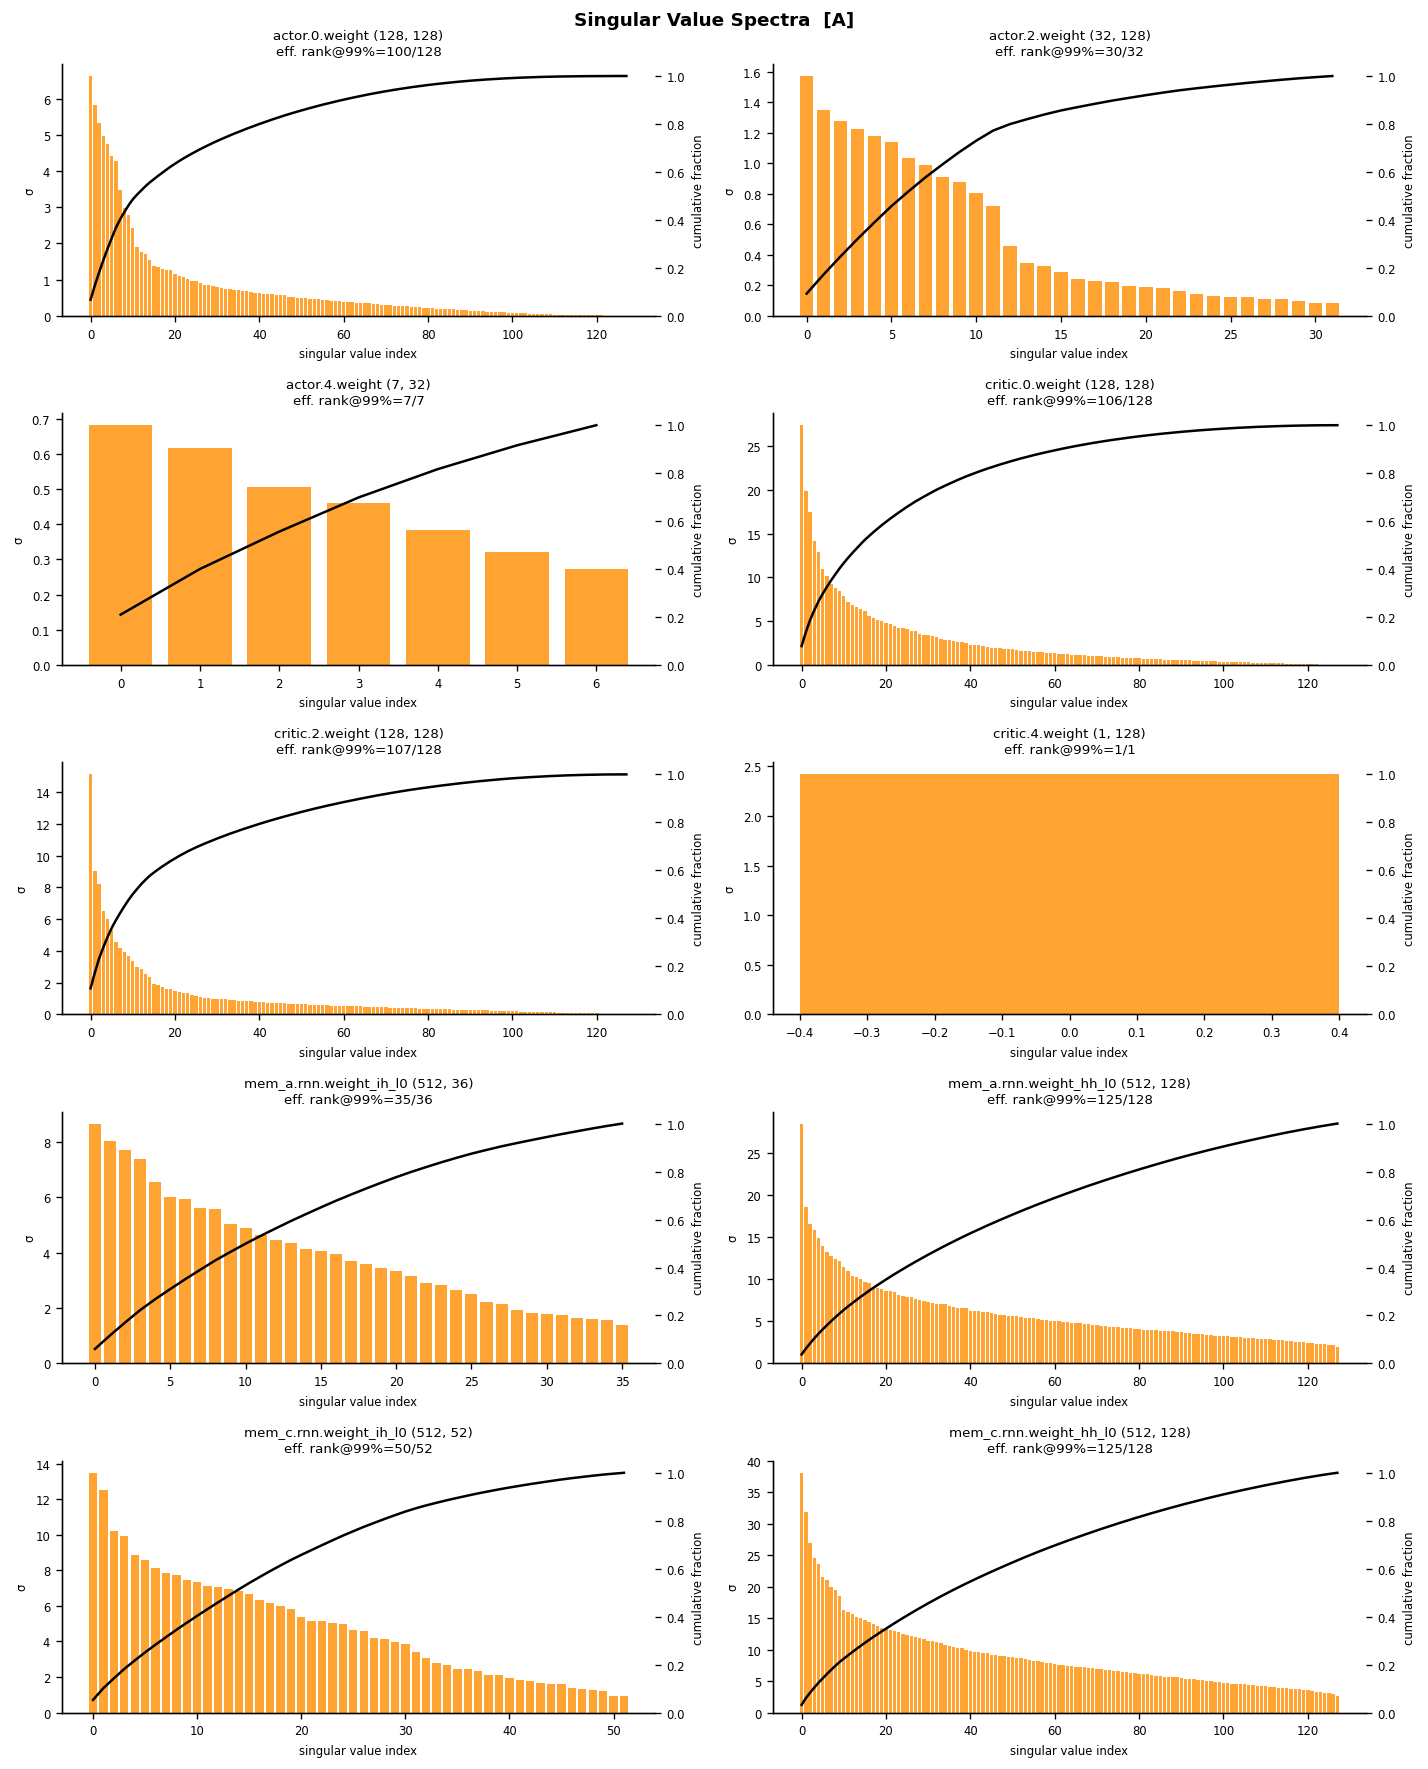

In [12]:
def plot_singular_values(sd: dict, label: str = "A"):
    """SVD of every 2-D weight matrix — shows effective rank."""
    weight_keys = [k for k, v in sd.items() if v.dim() == 2]
    if not weight_keys:
        return

    ncols = 2
    nrows = math.ceil(len(weight_keys) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 3))
    axes = np.array(axes).ravel()

    for i, key in enumerate(weight_keys):
        ax  = axes[i]
        mat = sd[key].float().numpy()
        # numpy svd — only singular values
        sv  = np.linalg.svd(mat, compute_uv=False)

        ax.bar(np.arange(len(sv)), sv, color="darkorange", alpha=0.8, width=0.8)
        # Cumulative explained fraction
        ax2 = ax.twinx()
        ax2.plot(np.cumsum(sv) / sv.sum(), "k-", linewidth=1.5)
        ax2.set_ylim(0, 1.05)
        ax2.set_ylabel("cumulative fraction", fontsize=7)
        ax2.tick_params(labelsize=7)

        # Effective rank (numerical rank at 99% energy)
        eff_rank = int(np.searchsorted(np.cumsum(sv) / sv.sum(), 0.99)) + 1
        label_str = key.replace("memory_a.", "mem_a.").replace("memory_c.", "mem_c.")
        ax.set_title(f"{label_str} {mat.shape}\neff. rank@99%={eff_rank}/{len(sv)}", fontsize=8)
        ax.set_xlabel("singular value index", fontsize=7)
        ax.set_ylabel("σ", fontsize=7)
        ax.tick_params(labelsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Singular Value Spectra  [{label}]", fontsize=11, fontweight="bold")
    fig.tight_layout()
    plt.show()


plot_singular_values(sd_a, label="A")
if sd_b is not None:
    plot_singular_values(sd_b, label="B")

## 7 · LSTM gate decomposition

PyTorch stores LSTM weights as a single `(4·H, input)` matrix in **[i, f, g, o]** order.  
Splitting by gate shows whether each gate has learned a different structure.

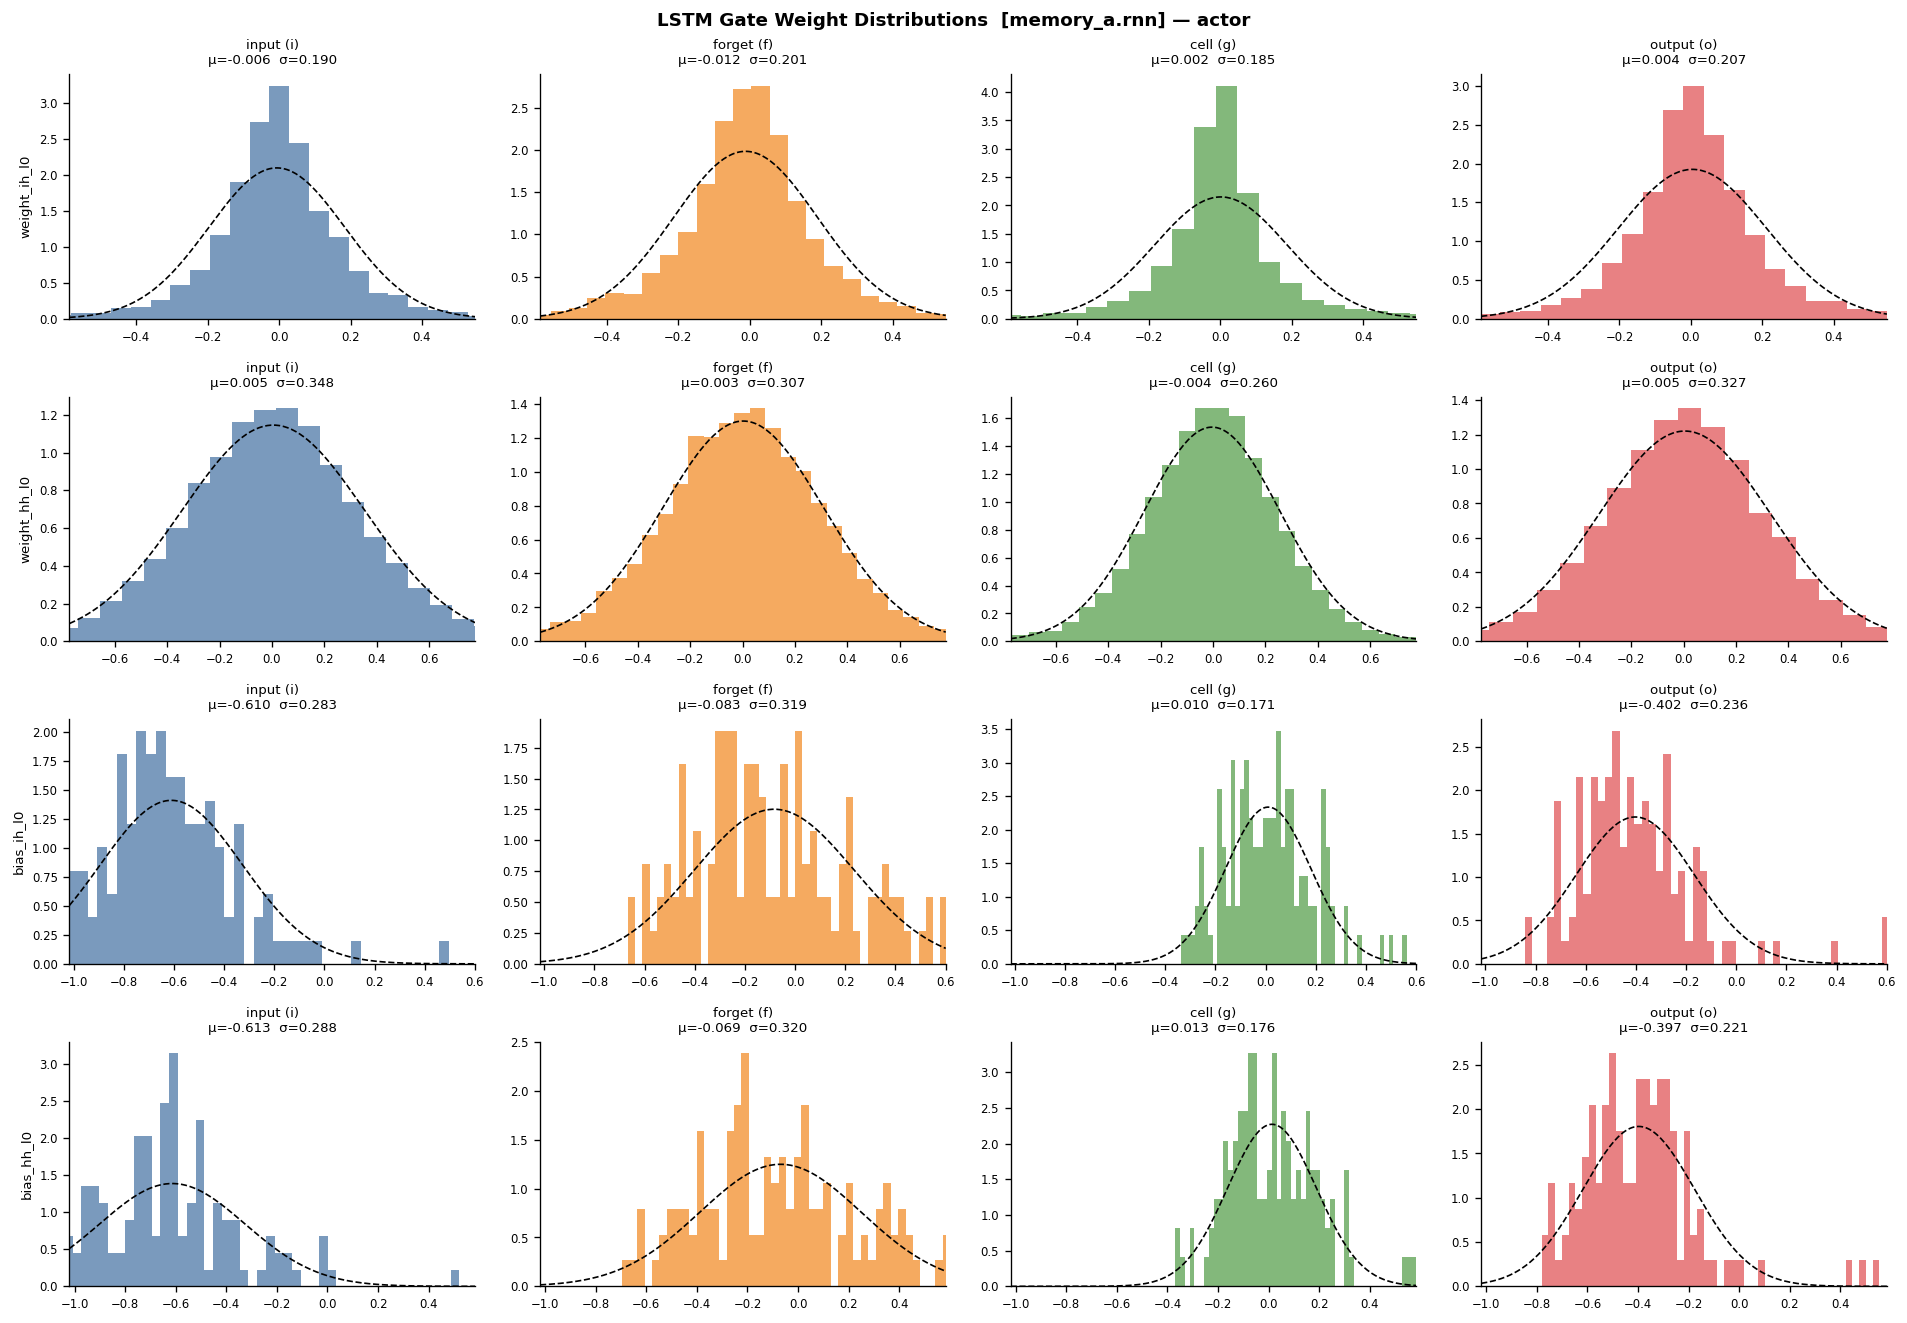

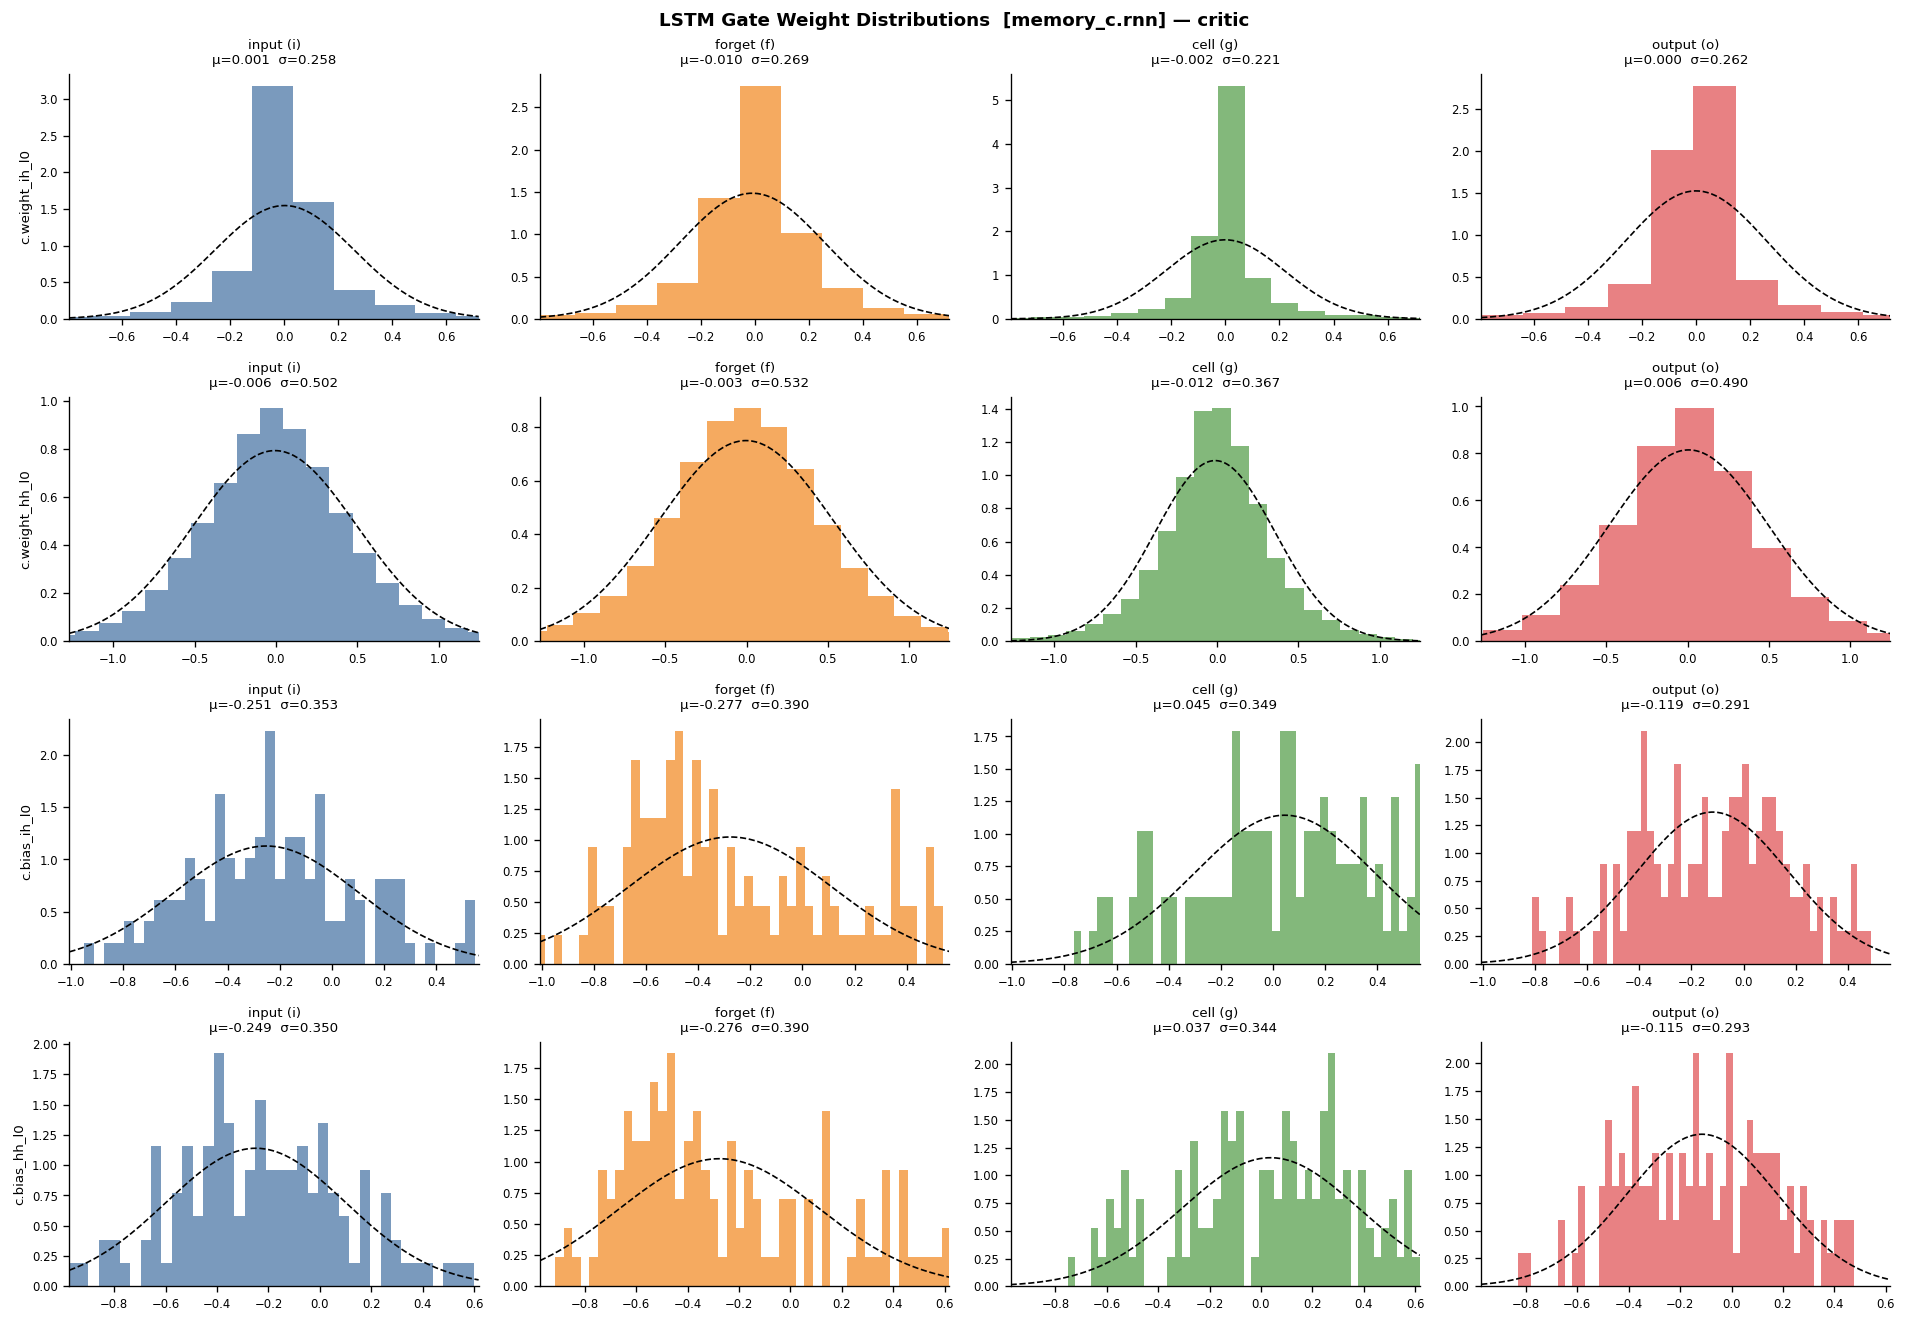

In [13]:
GATE_NAMES = ["input (i)", "forget (f)", "cell (g)", "output (o)"]
GATE_COLORS = ["#4e79a7", "#f28e2b", "#59a14f", "#e15759"]


def plot_lstm_gates(sd: dict, rnn_prefix: str = "memory_a.rnn", label: str = ""):
    """Compare weight distributions across the 4 LSTM gates."""
    ih_key = f"{rnn_prefix}.weight_ih_l0"
    hh_key = f"{rnn_prefix}.weight_hh_l0"
    bih_key = f"{rnn_prefix}.bias_ih_l0"
    bhh_key = f"{rnn_prefix}.bias_hh_l0"

    present = [k for k in [ih_key, hh_key, bih_key, bhh_key] if k in sd]
    if not present:
        print(f"No LSTM tensors found with prefix '{rnn_prefix}'")
        return

    fig, axes = plt.subplots(len(present), 4, figsize=(16, len(present) * 2.8))
    if len(present) == 1:
        axes = axes[np.newaxis, :]

    for row_i, key in enumerate(present):
        mat = sd[key].float().numpy()  # (4H, *)
        H   = mat.shape[0] // 4
        gates = [mat[g * H:(g + 1) * H].ravel() for g in range(4)]

        all_v = mat.ravel()
        lo, hi = np.percentile(all_v, 1), np.percentile(all_v, 99)
        xs = np.linspace(lo, hi, 200)

        for col_i, (gv, gname, col) in enumerate(zip(gates, GATE_NAMES, GATE_COLORS)):
            ax = axes[row_i, col_i]
            ax.hist(gv, bins=50, color=col, alpha=0.75, density=True, linewidth=0)
            mu, sig = gv.mean(), gv.std()
            if sig > 1e-9:
                ax.plot(xs,
                        np.exp(-0.5 * ((xs - mu) / sig) ** 2) / (sig * np.sqrt(2 * np.pi)),
                        "k--", linewidth=1.0)
            ax.set_title(f"{gname}\nμ={mu:.3f}  σ={sig:.3f}", fontsize=8)
            ax.set_xlim(lo, hi)
            ax.tick_params(labelsize=7)
            if col_i == 0:
                short = key.replace("memory_a.rnn.", "").replace("memory_c.rnn.", "c.")
                ax.set_ylabel(short, fontsize=8)

    fig.suptitle(f"LSTM Gate Weight Distributions  [{rnn_prefix}]{' — ' + label if label else ''}",
                 fontsize=11, fontweight="bold")
    fig.tight_layout()
    plt.show()


# Actor LSTM
plot_lstm_gates(sd_a, rnn_prefix="memory_a.rnn", label="actor")
# Critic LSTM
plot_lstm_gates(sd_a, rnn_prefix="memory_c.rnn", label="critic")

## 8 · Checkpoint comparison (A vs B)

Diff plots — only run when `CHECKPOINT_PATH_B` is set.

In [14]:
if sd_b is None:
    print("Set CHECKPOINT_PATH_B at the top of the notebook to enable comparison plots.")
else:
    common_keys = [k for k in sd_a if k in sd_b]

    # --- mean |ΔW| bar chart ---
    delta_means = []
    delta_max   = []
    names_short = []
    for k in common_keys:
        diff = (sd_b[k].float() - sd_a[k].float()).numpy().ravel()
        delta_means.append(np.mean(np.abs(diff)))
        delta_max.append(np.max(np.abs(diff)))
        names_short.append(k.replace("memory_a.", "mem_a.").replace("memory_c.", "mem_c."))

    x = np.arange(len(common_keys))
    fig, ax = plt.subplots(figsize=(max(8, len(common_keys) * 0.7), 4))
    ax.bar(x - 0.2, delta_means, 0.4, label="mean |ΔW|", color="steelblue", alpha=0.85)
    ax.bar(x + 0.2, delta_max,   0.4, label="max  |ΔW|", color="tomato",    alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(names_short, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("|ΔW|")
    ax.set_title("Weight Change A → B (per layer)")
    ax.legend()
    fig.tight_layout()
    plt.show()

    # --- overlaid histograms for each layer ---
    ncols = 3
    nrows = math.ceil(len(common_keys) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 2.8))
    axes = np.array(axes).ravel()
    for i, k in enumerate(common_keys):
        ax = axes[i]
        va = sd_a[k].float().numpy().ravel()
        vb = sd_b[k].float().numpy().ravel()
        lo = min(va.min(), vb.min())
        hi = max(va.max(), vb.max())
        bins = np.linspace(lo, hi, 60)
        ax.hist(va, bins=bins, alpha=0.55, density=True, color="steelblue", label="A")
        ax.hist(vb, bins=bins, alpha=0.55, density=True, color="tomato",    label="B")
        ax.legend(fontsize=7, frameon=False)
        short = k.replace("memory_a.", "mem_a.").replace("memory_c.", "mem_c.")
        ax.set_title(f"{short}", fontsize=8)
        ax.tick_params(labelsize=7)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle("Distribution Overlay: A (blue) vs B (red)", fontsize=11, fontweight="bold")
    fig.tight_layout()
    plt.show()

Set CHECKPOINT_PATH_B at the top of the notebook to enable comparison plots.


## 9 · Actor last-layer focus

The Hebbian rule acts **only** on `actor.4.weight` (the last `Linear(64→7)`).  
This cell gives it a dedicated close-up: per-output-neuron weight profile and activation-output correlation.

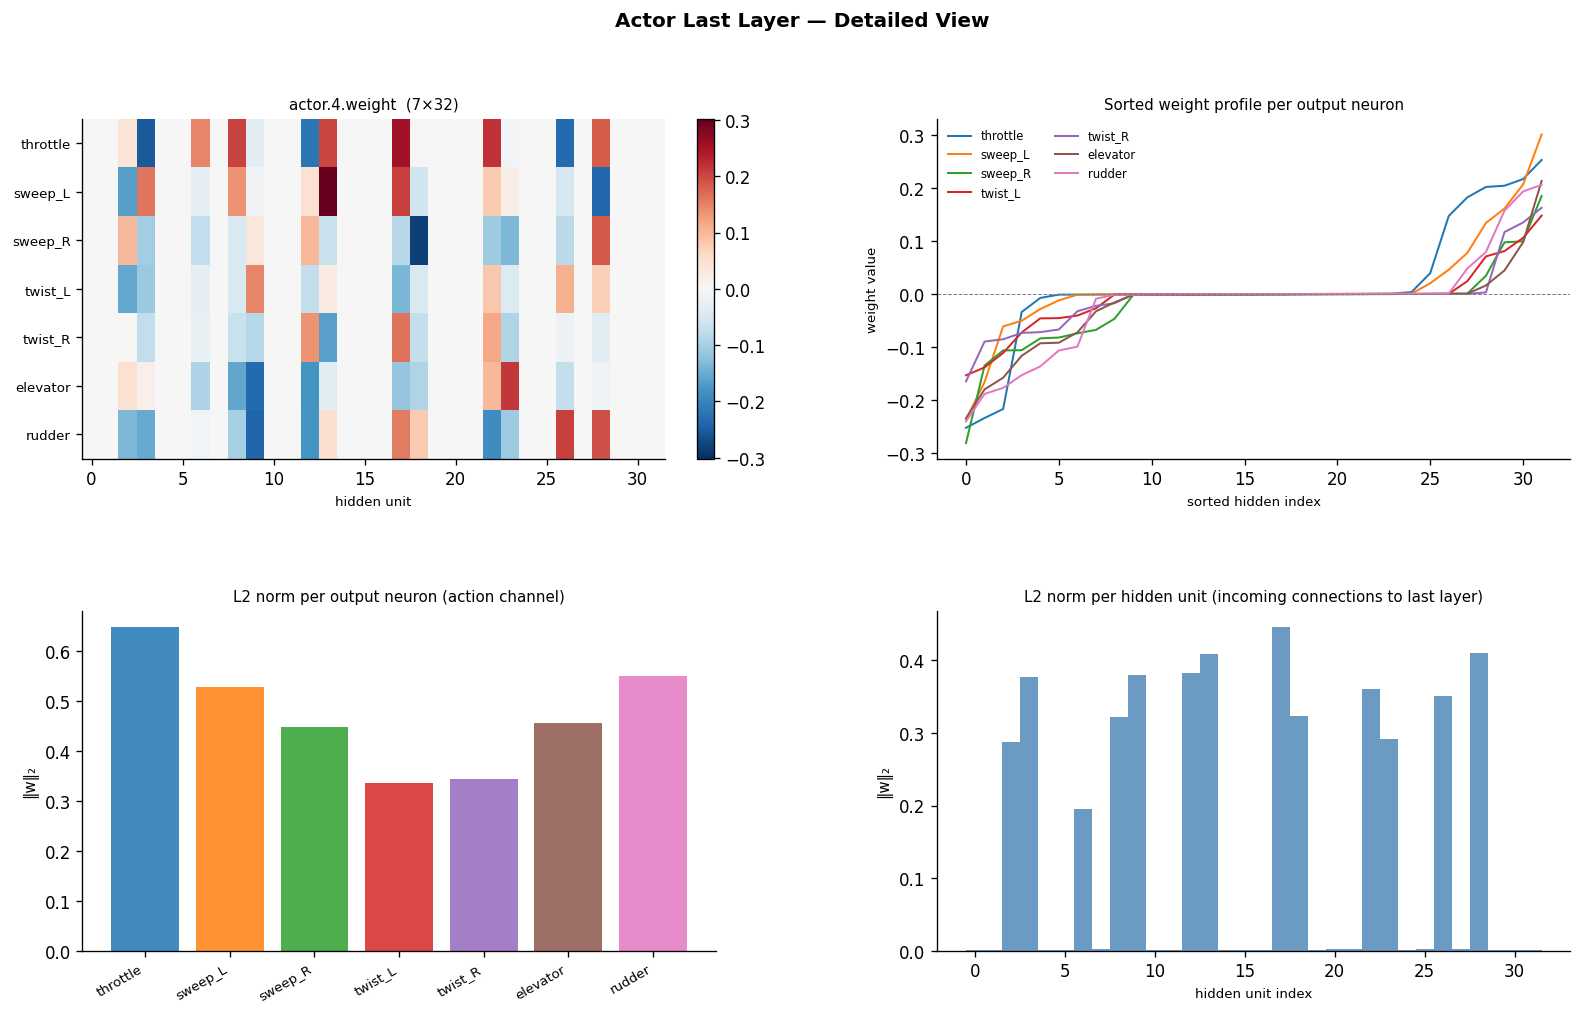

In [15]:
ACTION_NAMES = ["throttle", "sweep_L", "sweep_R", "twist_L", "twist_R", "elevator", "rudder"]

last_key = "actor.4.weight"  # (7, 64)

if last_key not in sd_a:
    print(f"Key '{last_key}' not found — adjust last_key above to match your checkpoint.")
else:
    W = sd_a[last_key].float().numpy()  # (out, in) = (7, 64)
    n_out, n_in = W.shape

    fig = plt.figure(figsize=(16, 9))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    # --- (a) Heatmap ---
    ax1 = fig.add_subplot(gs[0, 0])
    vabs = np.abs(W).max()
    im   = ax1.imshow(W, aspect="auto", cmap="RdBu_r",
                      norm=TwoSlopeNorm(vmin=-vabs, vcenter=0, vmax=vabs),
                      interpolation="nearest")
    plt.colorbar(im, ax=ax1, fraction=0.03)
    ax1.set_yticks(range(n_out))
    ax1.set_yticklabels(ACTION_NAMES[:n_out], fontsize=8)
    ax1.set_xlabel("hidden unit", fontsize=8)
    ax1.set_title(f"{last_key}  ({n_out}×{n_in})", fontsize=9)

    # --- (b) Per-output weight distribution ---
    ax2 = fig.add_subplot(gs[0, 1])
    for j in range(n_out):
        row = W[j]
        ax2.plot(sorted(row), label=ACTION_NAMES[j] if j < len(ACTION_NAMES) else str(j),
                 linewidth=1.2)
    ax2.axhline(0, color="gray", linewidth=0.6, linestyle="--")
    ax2.set_xlabel("sorted hidden index", fontsize=8)
    ax2.set_ylabel("weight value", fontsize=8)
    ax2.set_title("Sorted weight profile per output neuron", fontsize=9)
    ax2.legend(fontsize=7, ncol=2, frameon=False)

    # --- (c) L2 norm per output neuron ---
    ax3 = fig.add_subplot(gs[1, 0])
    norms = np.linalg.norm(W, axis=1)
    bars  = ax3.bar(range(n_out), norms, color=[f"C{j}" for j in range(n_out)], alpha=0.85)
    ax3.set_xticks(range(n_out))
    ax3.set_xticklabels(ACTION_NAMES[:n_out], rotation=30, ha="right", fontsize=8)
    ax3.set_ylabel("‖w‖₂", fontsize=9)
    ax3.set_title("L2 norm per output neuron (action channel)", fontsize=9)

    # --- (d) L2 norm per input (hidden) neuron ---
    ax4 = fig.add_subplot(gs[1, 1])
    col_norms = np.linalg.norm(W, axis=0)
    ax4.bar(range(n_in), col_norms, color="steelblue", alpha=0.8, width=1.0)
    ax4.set_xlabel("hidden unit index", fontsize=8)
    ax4.set_ylabel("‖w‖₂", fontsize=9)
    ax4.set_title("L2 norm per hidden unit (incoming connections to last layer)", fontsize=9)

    fig.suptitle("Actor Last Layer — Detailed View", fontsize=12, fontweight="bold")
    plt.show()

## 10 · Multi-checkpoint evolution over training

If you have a run directory with `model_N.pt` snapshots, this cell plots how weight statistics evolve across iterations.

In [16]:
# ── Configuration ──────────────────────────────────────────────────────────────
RUN_DIR = None   # e.g. "../logs/remote/wp1_training/some_run/logs/runs/2026-.../tb"
# ───────────────────────────────────────────────────────────────────────────────

if RUN_DIR is None:
    print("Set RUN_DIR to a directory containing model_*.pt snapshots to enable this analysis.")
else:
    run_path = Path(RUN_DIR)
    ckpt_files = sorted(run_path.glob("model_*.pt"),
                        key=lambda p: int(p.stem.split("_")[-1]))
    if not ckpt_files:
        print(f"No model_*.pt found in {run_path}")
    else:
        print(f"Found {len(ckpt_files)} checkpoints: {[p.stem for p in ckpt_files]}")

        # Track mean|w| and std for a few key layers across iterations
        TRACK_KEYS = ["actor.4.weight", "actor.0.weight", "actor.2.weight",
                      "memory_a.rnn.weight_ih_l0"]

        history = {k: {"iter": [], "mean_abs": [], "std": [], "l2": []} for k in TRACK_KEYS}

        for p in ckpt_files:
            sd_, meta_ = load_state_dict(str(p))
            it = meta_.get("iter", int(p.stem.split("_")[-1]))
            for k in TRACK_KEYS:
                if k not in sd_:
                    continue
                v = sd_[k].float().numpy().ravel()
                history[k]["iter"].append(it)
                history[k]["mean_abs"].append(np.mean(np.abs(v)))
                history[k]["std"].append(np.std(v))
                history[k]["l2"].append(np.linalg.norm(v))

        available = [k for k in TRACK_KEYS if history[k]["iter"]]
        fig, axes = plt.subplots(len(available), 3,
                                 figsize=(15, len(available) * 2.5), squeeze=False)

        for row, key in enumerate(available):
            h   = history[key]
            itr = h["iter"]
            axes[row, 0].plot(itr, h["mean_abs"], "o-", markersize=4)
            axes[row, 0].set_title(f"{key} — mean |w|", fontsize=8)
            axes[row, 1].plot(itr, h["std"],      "o-", markersize=4, color="tomato")
            axes[row, 1].set_title(f"{key} — σ(w)", fontsize=8)
            axes[row, 2].plot(itr, h["l2"],       "o-", markersize=4, color="darkorange")
            axes[row, 2].set_title(f"{key} — ‖W‖_F", fontsize=8)
            for c in range(3):
                axes[row, c].set_xlabel("training iter", fontsize=7)
                axes[row, c].tick_params(labelsize=7)

        fig.suptitle(f"Weight Statistics over Training — {run_path.name}",
                     fontsize=11, fontweight="bold")
        fig.tight_layout()
        plt.show()

Set RUN_DIR to a directory containing model_*.pt snapshots to enable this analysis.
